### Naive Bayes Classifier Task
### 문장에서 느껴지는 감정 예측
##### 다중 분류(Multiclass Classification)
- 비대면 심리 상담사로서 메세지를 전달한 환자에 대한 감정 데이터를 수집했다.
- 각 메세지 별로 감정이 표시되어 있다.
- 미래에 동일한 메세지를 보내는 환자에게 어떤 심리 치료가 적합할 수 있는지 알아보기 위한 모델을 구축한다.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score)

def get_evaluation(y_test, prediction, proba, class_names=None):
    confusion = confusion_matrix(y_test, prediction)
    accuracy = accuracy_score(y_test, prediction)
    
    # 다중 분류일 경우 precision과 recall, f1, roc_auc에 average 인자가 필요.
    # macro: 타겟별 F1점수 산술 평군, 모든 타겟을 동일한 비중으로 취급
    # micro: "정확도" 평가 지표와 수학적으로 동일한 값
    # weighted: 타겟별 F1점수에 해당 샘플 수만큼 가중치 부여, 다수 클래스의 영향력이 커짐
    precision = precision_score(y_test, prediction, average='weighted')
    recall = recall_score(y_test, prediction, average='weighted')
    f1 = f1_score(y_test, prediction, average='weighted')
    # ovr(One-vs-Rest): 여러 개의 타겟 중 1개 뽑아서 나머지와 비교(O, X), 직관적, 많이 씀
    # ovo(One-vs-One): 여러 개의 타겟 중 2개 뽑아서 서로 비교(A, B), 세밀함, 특별한 상황에서 씀
    roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted')

    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')
    print("#" * 75)
    
    # 클래스 개수에 따라 유동적으로 크기 조절
    num_classes = len(np.unique(y_test))
    fig_width = max(10, num_classes * 1.5)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(fig_width, 5))
    titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

    for (title, normalize), ax in zip(titles_options, axes.flatten()):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_true=y_test, y_pred=prediction,
            display_labels=class_names, # 클래스 이름 표시
            ax=ax, 
            cmap=plt.cm.Blues, 
            normalize=normalize,
            values_format='.2f' if normalize else 'd'
        )
        disp.ax_.set_title(title)
        
        # 레이블이 많을 경우 45도 회전하여 겹침 방지
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    plt.tight_layout()
    plt.show()

#### 다중분류에서 f1 스코어 보는 함수
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

In [2]:
import pandas as pd

f_df = pd.read_csv('./datasets/feeling.csv', sep=';')
f_df

,message,feeling
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy
...,...,...
17995,i just had a very brief time in the beanbag an...,sadness
17996,i am now turning and i feel pathetic that i am...,sadness
17997,i feel strong and good overall,joy
17998,i feel like this was such a rude comment and i...,anger


In [3]:
f_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  18000 non-null  object
 1   feeling  18000 non-null  object
dtypes: object(2)
memory usage: 281.4+ KB


In [4]:
f_df.isna().sum()

message    0
feeling    0
dtype: int64

In [5]:
f_df.duplicated().sum()
# f_df[f_df.duplicated()]
# f_df[f_df.index == 15846]
f_df[f_df.message.str.contains('i feel more adventurous willing')]

,message,feeling
6975,i feel more adventurous willing to take risks ...,joy
8007,i feel more adventurous willing to take risks,joy
15846,i feel more adventurous willing to take risks ...,joy


In [6]:
f_df.drop_duplicates(inplace=True, ignore_index=True)
f_df

,message,feeling
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy
...,...,...
17994,i just had a very brief time in the beanbag an...,sadness
17995,i am now turning and i feel pathetic that i am...,sadness
17996,i feel strong and good overall,joy
17997,i feel like this was such a rude comment and i...,anger


In [7]:
f_df.feeling.value_counts()

feeling
joy         6065
sadness     5216
anger       2434
fear        2149
love        1482
surprise     653
Name: count, dtype: int64

In [8]:
f_df = f_df[f_df.feeling != 'surprise']
f_df

,message,feeling
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy
...,...,...
17994,i just had a very brief time in the beanbag an...,sadness
17995,i am now turning and i feel pathetic that i am...,sadness
17996,i feel strong and good overall,joy
17997,i feel like this was such a rude comment and i...,anger


#### feeling의 값이 'surprise' 인 데이터의 개수가 상대적으로 적어 해당 카테고리의 데이터를 제거한다.

In [9]:
from sklearn.preprocessing import LabelEncoder

f_encoder = LabelEncoder()
targets = f_encoder.fit_transform(f_df.feeling)

f_df['target'] = targets
f_df

C:\Users\sokko\AppData\Local\Temp\ipykernel_2624\580341574.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['target'] = targets


,message,feeling,target
0,im feeling quite sad and sorry for myself but ...,sadness,4
1,i feel like i am still looking at a blank canv...,sadness,4
2,i feel like a faithful servant,love,3
3,i am just feeling cranky and blue,anger,0
4,i can have for a treat or if i am feeling festive,joy,2
...,...,...,...
17994,i just had a very brief time in the beanbag an...,sadness,4
17995,i am now turning and i feel pathetic that i am...,sadness,4
17996,i feel strong and good overall,joy,2
17997,i feel like this was such a rude comment and i...,anger,0


In [10]:
f_encoder

LabelEncoder()

In [11]:
f_df.target.value_counts()

target
2    6065
4    5216
0    2434
1    2149
3    1482
Name: count, dtype: int64

#### 각 수치별 감정
- 0: anger
- 1: fear
- 2: joy
- 3: love
- 4: sadness

In [12]:
target_0 = f_df[f_df.target == 0].sample(1482, random_state=326)
target_1 = f_df[f_df.target == 1].sample(1482, random_state=326)
target_2 = f_df[f_df.target == 2].sample(1482, random_state=326)
target_3 = f_df[f_df.target == 3]
target_4 = f_df[f_df.target == 4].sample(1482, random_state=326)

f_df = pd.concat([target_0, target_1, target_2, target_3, target_4])
f_df.target.value_counts()

target
0    1482
1    1482
2    1482
3    1482
4    1482
Name: count, dtype: int64

In [13]:
f_df

,message,feeling,target
17960,i am walking around feeling quite tortured bec...,anger,0
16407,i was feeling so spiteful i brought it up and ...,anger,0
5026,i feel too rushed,anger,0
7941,i feel so impatient and sometimes i feel thank...,anger,0
17714,i am feeling a little irritated with some clos...,anger,0
...,...,...,...
12644,i didnt want to stay in this feeling of loneli...,sadness,4
12336,i feel a bit foolish now because in the last y...,sadness,4
4034,i was feeling quite stressed wondering if he w...,sadness,4
10073,i would recommend it strongly for any who feel...,sadness,4


In [14]:
f_df.drop(['feeling'], axis=1, inplace=True)
f_df

,message,target
17960,i am walking around feeling quite tortured bec...,0
16407,i was feeling so spiteful i brought it up and ...,0
5026,i feel too rushed,0
7941,i feel so impatient and sometimes i feel thank...,0
17714,i am feeling a little irritated with some clos...,0
...,...,...
12644,i didnt want to stay in this feeling of loneli...,4
12336,i feel a bit foolish now because in the last y...,4
4034,i was feeling quite stressed wondering if he w...,4
10073,i would recommend it strongly for any who feel...,4


In [15]:
f_df.reset_index(drop=True)

,message,target
0,i am walking around feeling quite tortured bec...,0
1,i was feeling so spiteful i brought it up and ...,0
2,i feel too rushed,0
3,i feel so impatient and sometimes i feel thank...,0
4,i am feeling a little irritated with some clos...,0
...,...,...
7405,i didnt want to stay in this feeling of loneli...,4
7406,i feel a bit foolish now because in the last y...,4
7407,i was feeling quite stressed wondering if he w...,4
7408,i would recommend it strongly for any who feel...,4


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
train_test_split(f_df.message, f_df.target, stratify=f_df.target, test_size=0.3, random_state=124)

In [17]:
y_test.value_counts()

target
1    445
4    445
2    445
0    444
3    444
Name: count, dtype: int64

#### MultinomialNB()
`가장 대중적으로 사용되는 모델로, 데이터의 출현 빈도(Counts)를 다룰 때 최적이다.`
- alpha: 기본값은 1.0이고, 전체 단어의 빈도수에 alpha값을 더해준다.  
  학습 데이터에 없던 단어가 실제 데이터에 있다면 해당 단어의 확률은 0이 된다.  
이런 상황을 보정하기 위해서 모든 단어의 빈도수에 아주 작은 값(alpha)을 더하여 0이 되지 않게 한다.
- 특징(Feature) 간의 관계를 깊게 파고드는 게 아니라 단어의 빈도수만 따지기 때문에, alpha 값 외에는 모델의 구조 자체를 바꿀 하이퍼 파라미터가 거의 없다.
- 하이퍼파라미터 튜닝보다는 텍스트 전처리를 어떻게 하느냐가 중요하다.

#### BernoulliNB()
`텍스트 길이가 아주 짧아서 특정 단어의 등장만으로도 1로 표현하고자 할 때`
- alpha: 기본값은 1.0이고, 전체 단어의 빈도수에 alpha값을 더해준다.  
- 데이터의 유무에만 집중하는 모델로, 입력 데이터가 빈도수(2번, 5번 등)로 들어오더라도, 내부적으로는 1(등장함)과 0(등장 안 함)으로 변환하여 처리한다.
- 트위터, SMS 메시지, 상품 리뷰 한 줄 평처럼 문장이 짧아 단어 빈도수가 큰 의미가 없을 때 유리하다.

#### GaussianNB()
`feature가 횟수가 아닌 연속적인 수치(연속형 데이터)일 때`
- 데이터 양이 매우 적을 때(클래스당 30개 내외) 결정 트리보다 안정적일 수 있으며, 학습 속도가 압도적으로 빠르다.
- 평균과 표준편차를 구해 확률을 계산하기 때문에, 데이터 양이 적어도 효과적이다.
- 실제 데이터가 정규 분포를 따르지 않거나 변수 간의 상관관계가 높으면 성능이 급격히 떨어진다.
- 계산 비용을 극도로 아껴야 하는 환경에서 고려해볼만하다(아두이노, 라즈베리파이 등 특정 보드나 칩셋).

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

m_nb_pipe = Pipeline(
    [
        ('count_vectorizer', CountVectorizer()), 
        ('multinomial_NB', MultinomialNB())
    ]
)
# MultinomialNB() 에 알파값은 주지 않는다.

m_nb_pipe.fit(X_train.values, y_train)


,steps,"[('count_vectorizer', ...), ('multinomial_NB', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [19]:
m_nb_pipe.score(X_test.values, y_test)

0.8029689608636977

#### 각 수치별 감정
- 0: anger
- 1: fear
- 2: joy
- 3: love
- 4: sadness

In [20]:
print(m_nb_pipe.predict(['the project that i am testing is feeling check', 
                         'i am happy now']))

[1 2]


In [21]:
prediction = m_nb_pipe.predict(X_test.values)
proba = m_nb_pipe.predict_proba(X_test.values)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       444
           1       0.81      0.82      0.82       445
           2       0.78      0.75      0.76       445
           3       0.77      0.87      0.82       444
           4       0.80      0.76      0.78       445

    accuracy                           0.80      2223
   macro avg       0.80      0.80      0.80      2223
weighted avg       0.80      0.80      0.80      2223



오차 행렬
[[361  29  13  20  21]
 [ 22 366  14  17  26]
 [ 13  23 333  55  21]
 [  5   5  33 387  14]
 [ 21  30  33  23 338]]
정확도: 0.8030, 정밀도: 0.8041, 재현율: 0.8030, F1: 0.8026, AUC: 0.9450
###########################################################################


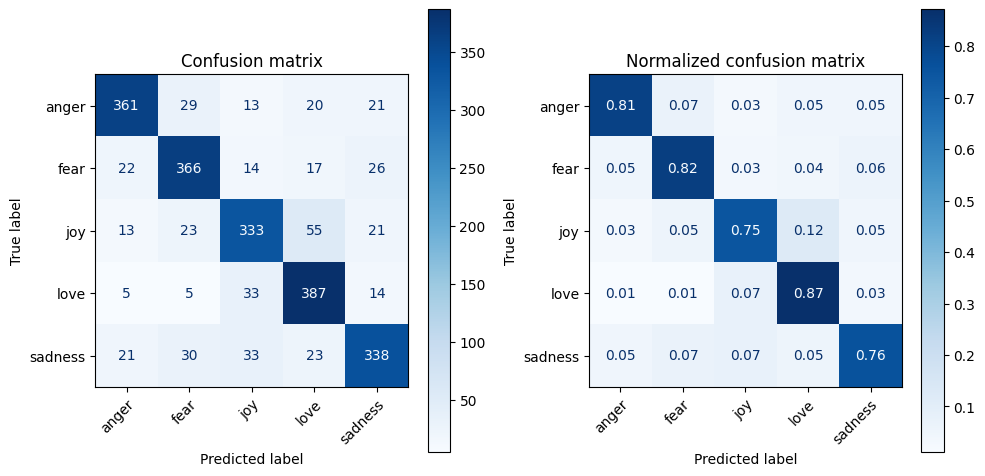

In [23]:
get_evaluation(y_test, prediction, proba, class_names=f_encoder.classes_)

In [27]:
import joblib

joblib.dump(m_nb_pipe, 'feeling_model.pkl')

['feeling_model.pkl']

In [28]:
import joblib

joblib.dump(f_encoder, 'feeling_encoded.pkl')

['feeling_encoded.pkl']

In [24]:
f_encoder.classes_

array(['anger', 'fear', 'joy', 'love', 'sadness'], dtype=object)